# Employee Attrition Prediction and Analysis

## 1. Introduction

### Project Overview
This project aims to predict employee attrition (whether an employee will leave the company) using machine learning techniques. By analyzing historical HR data including satisfaction levels, work patterns, and employment history, we will build a predictive model to identify employees at risk of attrition. The model will help HR teams take proactive measures to improve retention.


### Data Description
We have two datasets:

**1. hr_data.csv**  
Contains work-related attributes for ~15,000 employees:
- `employee_id`: Unique identifier
- `number_project`: Projects assigned (2-7)
- `average_montly_hours`: Hours worked (96-310)
- `time_spend_company`: Years at company
- `Work_accident`: Workplace accident (0/1)
- `left`: Target variable (0=stayed, 1=left)
- `promotion_last_5years`: Promotion status (0/1)
- `department`: Work department
- `salary`: Relative salary level (high/medium/low)

**2. employee_satisfaction_evaluation.xlsx**  
Contains employee evaluation metrics:
- `EMPLOYEE #`: Matching employee_id
- `satisfaction_level`: Self-reported (0-1 scale)
- `last_evaluation`: Manager assessment (0-1 scale)

#**Data Loading and Initial Exploration**

## 1) Importing Libraries

In [ ]:

# Import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings

warnings.filterwarnings ('ignore')



##2) Loading HR Data

### Read & Display head

In [ ]:
hr_df=pd.read_csv('/content/drive/MyDrive/Employee Attrition/hr_data.csv')
hr_df.head()

,employee_id,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary
0,1003,2,157,3,0,1,0,sales,low
1,1005,5,262,6,0,1,0,sales,medium
2,1486,7,272,4,0,1,0,sales,medium
3,1038,5,223,5,0,1,0,sales,low
4,1057,2,159,3,0,1,0,sales,low


### Shape

In [ ]:
hr_df.shape

(14999, 9)

###Check data Type

In [ ]:
dtypes=hr_df.dtypes
nuniques=hr_df.nunique()
pd.DataFrame({"Dtype":dtypes,"Nunique":nuniques})


,Dtype,Nunique
employee_id,int64,14999
number_project,int64,6
average_montly_hours,int64,215
time_spend_company,int64,8
Work_accident,int64,2
left,int64,2
promotion_last_5years,int64,2
department,object,10
salary,object,3


In [ ]:

#cat_columns = ['Work_accident', 'left', 'promotion_last_5years','department','salary']
#for col in cat_columns:
    #hr_df[col] = hr_df[col].astype('category')

In [ ]:
cat_map = {
    'binary': ['Work_accident', 'left', 'promotion_last_5years'],
    'nominal': ['department'],
    'ordinal': ['salary']
}
for col in cat_map['binary']:
    hr_df[col] = hr_df[col].astype('bool')

hr_df['department'] = hr_df['department'].astype('category')
hr_df['salary'] = pd.Categorical(hr_df['salary'], categories=['low','medium','high'],ordered=True)


In [ ]:
hr_df

,employee_id,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary
0,1003,2,157,3,False,True,False,sales,low
1,1005,5,262,6,False,True,False,sales,medium
2,1486,7,272,4,False,True,False,sales,medium
3,1038,5,223,5,False,True,False,sales,low
4,1057,2,159,3,False,True,False,sales,low
...,...,...,...,...,...,...,...,...,...
14994,87670,2,151,3,False,True,False,support,low
14995,87673,2,160,3,False,True,False,support,low
14996,87679,2,143,3,False,True,False,support,low
14997,87681,6,280,4,False,True,False,support,low


### info

In [ ]:
hr_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   employee_id            14999 non-null  int64   
 1   number_project         14999 non-null  int64   
 2   average_montly_hours   14999 non-null  int64   
 3   time_spend_company     14999 non-null  int64   
 4   Work_accident          14999 non-null  bool    
 5   left                   14999 non-null  bool    
 6   promotion_last_5years  14999 non-null  bool    
 7   department             14999 non-null  category
 8   salary                 14999 non-null  category
dtypes: bool(3), category(2), int64(4)
memory usage: 542.6 KB


##3) Loading Satisfaction Data

### Read & Display head

In [ ]:
s_df=pd.read_excel('/content/drive/MyDrive/Employee Attrition/employee_satisfaction_evaluation.xlsx')
s_df.head(10)

,EMPLOYEE #,satisfaction_level,last_evaluation
0,1003,0.38,0.53
1,1005,0.80,0.86
2,1486,0.11,0.88
3,1038,0.72,0.87
4,1057,0.37,0.52
5,1060,0.41,0.50
6,1061,0.10,0.77
7,1576,0.92,0.85
8,1752,0.89,1.00
9,1988,0.42,0.53


### Shape

In [ ]:
s_df.shape

(14999, 3)

###Check data Type

In [ ]:
dtypes=s_df.dtypes
nuniques=s_df.nunique()
pd.DataFrame({"Dtype":dtypes,"Nunique":nuniques})

,Dtype,Nunique
EMPLOYEE #,int64,14999
satisfaction_level,float64,92
last_evaluation,float64,65


### info

In [ ]:
s_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   EMPLOYEE #          14999 non-null  int64  
 1   satisfaction_level  14972 non-null  float64
 2   last_evaluation     14972 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 351.7 KB


##4) Data Merging

In [ ]:
main_df= hr_df.set_index('employee_id').join(s_df.set_index('EMPLOYEE #'))

In [ ]:
main_df=main_df.reset_index()

In [ ]:
main_df

,employee_id,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary,satisfaction_level,last_evaluation
0,1003,2,157,3,False,True,False,sales,low,0.38,0.53
1,1005,5,262,6,False,True,False,sales,medium,0.80,0.86
2,1486,7,272,4,False,True,False,sales,medium,0.11,0.88
3,1038,5,223,5,False,True,False,sales,low,0.72,0.87
4,1057,2,159,3,False,True,False,sales,low,0.37,0.52
...,...,...,...,...,...,...,...,...,...,...,...
14994,87670,2,151,3,False,True,False,support,low,0.40,0.57
14995,87673,2,160,3,False,True,False,support,low,0.37,0.48
14996,87679,2,143,3,False,True,False,support,low,0.37,0.53
14997,87681,6,280,4,False,True,False,support,low,0.11,0.96


# **Understand Data**

## 1. Basic Checks (shape , info )

In [ ]:
main_df.shape

(14999, 11)

In [ ]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   employee_id            14999 non-null  int64   
 1   number_project         14999 non-null  int64   
 2   average_montly_hours   14999 non-null  int64   
 3   time_spend_company     14999 non-null  int64   
 4   Work_accident          14999 non-null  bool    
 5   left                   14999 non-null  bool    
 6   promotion_last_5years  14999 non-null  bool    
 7   department             14999 non-null  category
 8   salary                 14999 non-null  category
 9   satisfaction_level     14972 non-null  float64 
 10  last_evaluation        14972 non-null  float64 
dtypes: bool(3), category(2), float64(2), int64(4)
memory usage: 776.9 KB


## 2. Duplicates & Nulls

In [ ]:
    print(f"Total rows: {len(main_df)}")
    print(f"Duplicate rows: {main_df.duplicated().sum()}")
    print(f"Duplicate employee IDs: {main_df['employee_id'].duplicated().sum()}")

Total rows: 14999
Duplicate rows: 0
Duplicate employee IDs: 0


In [ ]:
null= main_df.isna().sum()
null_ratio=(null/main_df.shape[0])*100
dtypes=main_df.dtypes
null_stats=pd.DataFrame({"NULL":null,"Null_ratio":null_ratio,"Data type":dtypes})
null_stats.style.format({
    'NULL': '{:,}',  # Format counts with commas
    'Null_ratio': '{:.2f}%'  # Explicit percentage format
})

,NULL,Null_ratio,Data type
employee_id,0,0.00%,int64
number_project,0,0.00%,int64
average_montly_hours,0,0.00%,int64
time_spend_company,0,0.00%,int64
Work_accident,0,0.00%,bool
left,0,0.00%,bool
promotion_last_5years,0,0.00%,bool
department,0,0.00%,category
salary,0,0.00%,category
satisfaction_level,27,0.18%,float64


 ## 3. Statistical Summary (describe)

In [ ]:
main_df.describe()

,employee_id,number_project,average_montly_hours,time_spend_company,satisfaction_level,last_evaluation
count,14999.000000,14999.000000,14999.000000,14999.000000,14972.000000,14972.000000
mean,45424.627575,3.803054,201.050337,3.498233,0.612830,0.716125
std,25915.900127,1.232592,49.943099,1.460136,0.248714,0.171138
min,1003.000000,2.000000,96.000000,2.000000,0.090000,0.360000
25%,22872.500000,3.000000,156.000000,3.000000,0.440000,0.560000
50%,45448.000000,4.000000,200.000000,3.000000,0.640000,0.720000
75%,67480.500000,5.000000,245.000000,4.000000,0.820000,0.870000
max,99815.000000,7.000000,310.000000,10.000000,1.000000,1.000000


In [ ]:
main_df.describe(include=["category","bool"])

,Work_accident,left,promotion_last_5years,department,salary
count,14999,14999,14999,14999,14999
unique,2,2,2,10,3
top,False,False,False,sales,low
freq,12830,11428,14680,4140,7316


## 4. Business Logic Checks

*   Company policies ("Promotions require 1+ year tenure")

*   Physical limits ("Monthly hours can’t exceed 744 [24 hrs/day × 31 days")

*   Domain knowledge ("Low satisfaction + high evaluation = burnout risk")

In [ ]:
promotion_anomalies = main_df[(main_df['promotion_last_5years'] == 1) &
                             (main_df['time_spend_company'] < 1)]


if not promotion_anomalies.empty:
    print(f"⚠️ {len(promotion_anomalies)} anomalous records found:")
    display(promotion_anomalies[['employee_id', 'time_spend_company', 'promotion_last_5years']])

    # Step 3: Decide action (example: exclude anomalies)
    main_df = main_df.drop(promotion_anomalies.index)
    print("Anomalies removed from dataset.")
else:
    print("✅ No promotion anomalies detected.")

✅ No promotion anomalies detected.


In [ ]:
# Check for impossible work hours (>744 hours/month)
overworked = main_df[main_df['average_montly_hours'] > 744]
print(f"Impossible work hours: {len(overworked)}")

Impossible work hours: 0


In [ ]:
# High evaluation but low satisfaction
burnout_risk = main_df[
    (main_df['last_evaluation'] > 0.8) &
    (main_df['satisfaction_level'] < 0.3)
]
print(f"High-performer burnout candidates: {len(burnout_risk)}")

High-performer burnout candidates: 1049


# **Data Exploration**
        
  1) For numeric data
      
      - Made histograms to understand distributions
      - Corrplot
      - Boxplots (to visualize outliyer)
      - Pivot table comparing left across numeric variables
      
  2) For Categorical Data
      
      - Balance of classes
      - Count plot
      - Made pivot tables to understand relationship with left
      


In [ ]:
main_df.describe().columns

Index(['employee_id', 'number_project', 'average_montly_hours',
       'time_spend_company', 'satisfaction_level', 'last_evaluation'],
      dtype='object')

In [ ]:
# we don't want cols --> employee_id
df_num = main_df[['number_project', 'average_montly_hours','time_spend_company', 'satisfaction_level', 'last_evaluation']]
df_cat = main_df[['Work_accident','left','promotion_last_5years','salary','department']]

## **1) Numeric Data Analysis**

### ***Histograms (data distripution)***

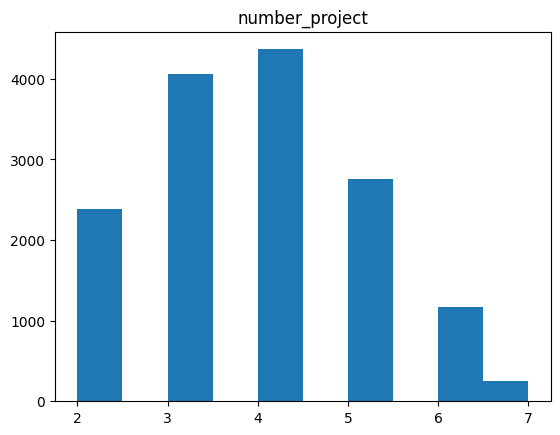

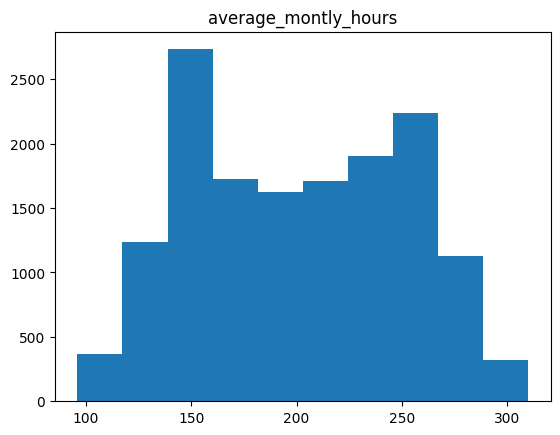

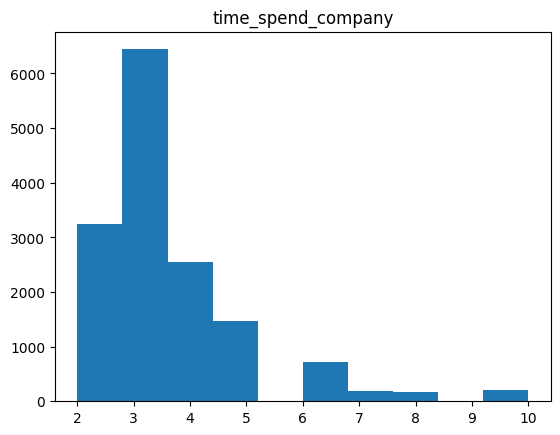

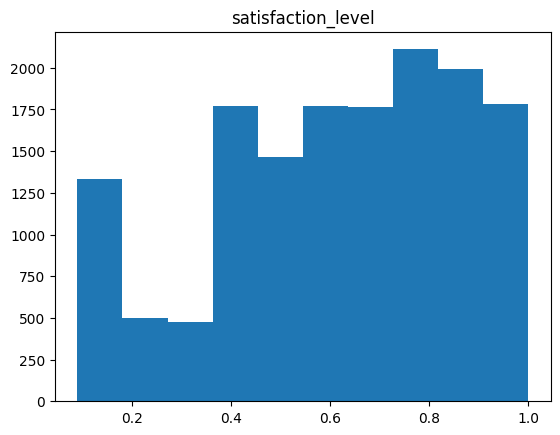

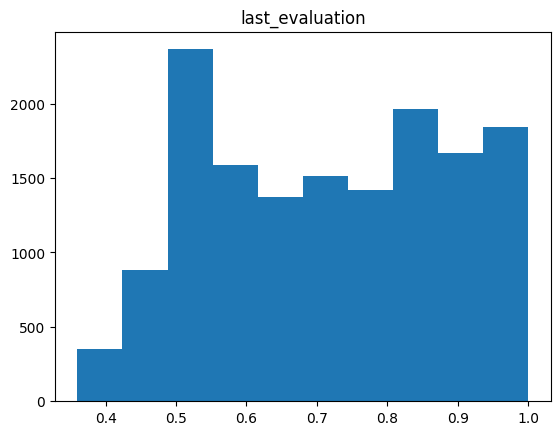

In [ ]:
# distributions for all numeric variables
for i in df_num.columns:
    plt.hist(df_num[i])
    plt.title(i)
    plt.show()

 **Insights from Employee Data Visualizations**
 *   Number of Projects
- Most employees (around 3,500-4,000) work on 3-4 projects
- Very few employees work on 2 projects or 7 projects
- The distribution peaks at 3-4 projects and declines sharply on either side



*   Average Monthly Hours
  - The majority of employees work between 150-250 hours per month
  - The peak is around 200 hours per month
  - Very few employees work less than 100 or more than 300 hours monthly

*    Time Spent at Company
  - Most employees have been with the company for 3 years
  - There's a steep decline after 3 years, with very few employees staying beyond 6 years
  - The distribution is heavily right-skewed

*    Satisfaction Level
  - Satisfaction appears bimodal with peaks around 0.4 and 0.8
  - Few employees report very low satisfaction (<0.2) or perfect satisfaction (1.0)
  - The largest group (around 1,750 employees) reports satisfaction around 0.4

*    Last Evaluation Score
  - Most employees receive evaluations between 0.6-0.9
  - The peak is around 0.8 (approximately 2,000 employees)
  - Very few employees score below 0.5 or perfect 1.0







### ***Correlation***

In [ ]:
df_num.corr()

,number_project,average_montly_hours,time_spend_company,satisfaction_level,last_evaluation
number_project,1.000000,0.417211,0.196786,-0.144011,0.349044
average_montly_hours,0.417211,1.000000,0.127755,-0.020908,0.339300
time_spend_company,0.196786,0.127755,1.000000,-0.101236,0.131190
satisfaction_level,-0.144011,-0.020908,-0.101236,1.000000,0.103881
last_evaluation,0.349044,0.339300,0.131190,0.103881,1.000000


In [ ]:
abs(df_num.corr())

,number_project,average_montly_hours,time_spend_company,satisfaction_level,last_evaluation
number_project,1.000000,0.417211,0.196786,0.144011,0.349044
average_montly_hours,0.417211,1.000000,0.127755,0.020908,0.339300
time_spend_company,0.196786,0.127755,1.000000,0.101236,0.131190
satisfaction_level,0.144011,0.020908,0.101236,1.000000,0.103881
last_evaluation,0.349044,0.339300,0.131190,0.103881,1.000000


<Axes: >

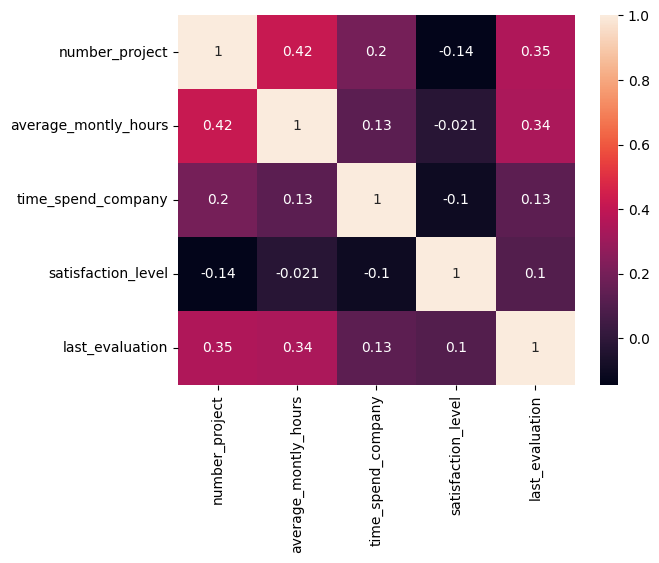

In [ ]:
sns.heatmap(df_num.corr(),annot=True)

 **Correlation Matrix Insights**

1. **Number of Projects vs. Average Monthly Hours (0.42)**
   - Moderate positive correlation indicating employees with more projects tend to work more hours

2. **Number of Projects vs. Last Evaluation (0.35)**
   - Employees with more projects tend to receive higher evaluation scores

3. **Average Monthly Hours vs. Last Evaluation (0.34)**
   - Employees who work more hours tend to get better evaluations


---


 **Weak or No Correlations**
1. **Satisfaction Level shows near-zero correlations** with:
   - Average Monthly Hours (-0.021)
   - Time Spent at Company (-0.1)
   - Last Evaluation (0.1)

2. **Time Spent at Company** has minimal correlation with:
   - Satisfaction Level (-0.1)
   - Last Evaluation (0.13)
   ---

**Negative Correlations**
1. **Satisfaction Level vs. Number of Projects (-0.14)**
   - Slight negative trend where more projects may decrease satisfaction
  



### ***Boxplots***

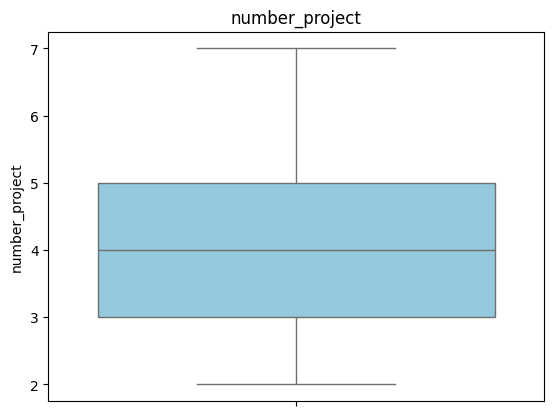

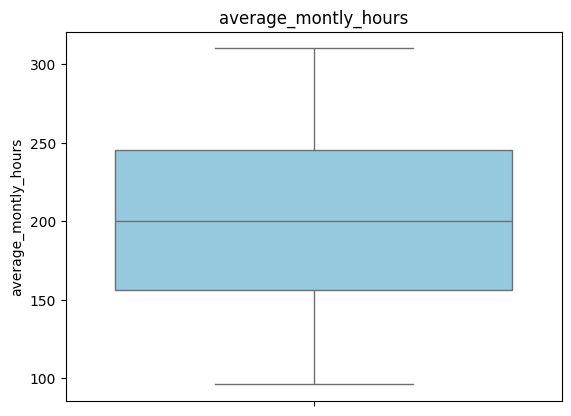

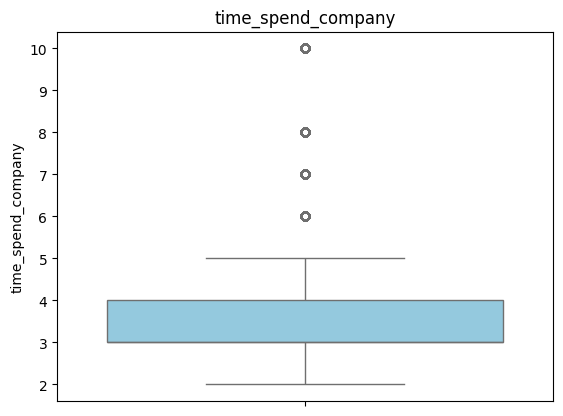

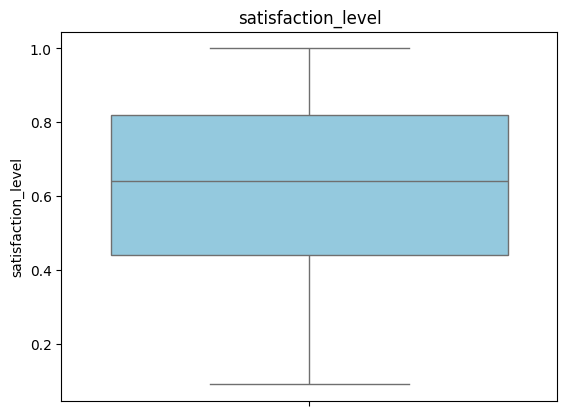

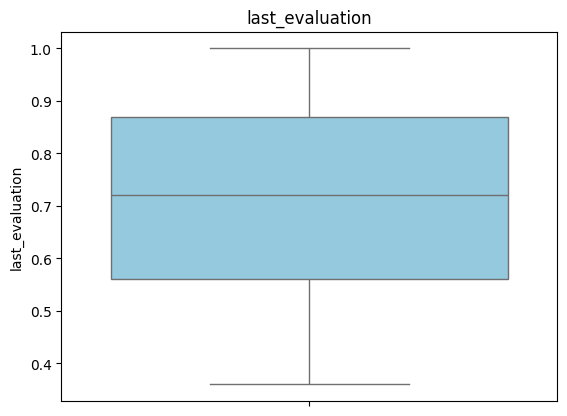

In [ ]:
# distributions for all numeric variables
for i in df_num.columns:
    sns.boxplot(y=main_df[i], color='skyblue')
    plt.title(i)
    plt.show()



 **1. Satisfaction Level**  
- Left-Skewed (Peak at high satisfaction)  


 **2. Last Evaluation**  
- Right-Skewed (Peak at high scores)  


 **3. Time Spent at Company**  
- Right-Skewed (Most leave by 5 years)  
- Outliers:  **>6 years** (rare long tenure)  

**4. Number of Projects**  
- Mild Left-Skewed (Most have 3-5 projects)  

**5. Average Monthly Hours**  
- Near-Normal (Peak ~200 hours)  




### ***Pivot table comparing left across numeric variables***

In [ ]:
# Create crosstab with clear labels and totals
project_retention = pd.crosstab(
    main_df['number_project'],
    main_df['left'].map({True: 'Left', False: 'Stayed'}),

    margins=True,  # Adds row/column totals
    margins_name='All'
)
project_retention

left,Left,Stayed,All
number_project,,,
2,1567,821,2388
3,72,3983,4055
4,409,3956,4365
5,612,2149,2761
6,655,519,1174
7,256,0,256
All,3571,11428,14999


In [ ]:
# Add percentage columns
project_retention['Leave Rate (%)'] = (
    project_retention['Left'] /
    (project_retention['Stayed'] + project_retention['Left']) * 100
).round(1)

project_retention

left,Left,Stayed,All,Leave Rate (%)
number_project,,,,
2,1567,821,2388,65.6
3,72,3983,4055,1.8
4,409,3956,4365,9.4
5,612,2149,2761,22.2
6,655,519,1174,55.8
7,256,0,256,100.0
All,3571,11428,14999,23.8


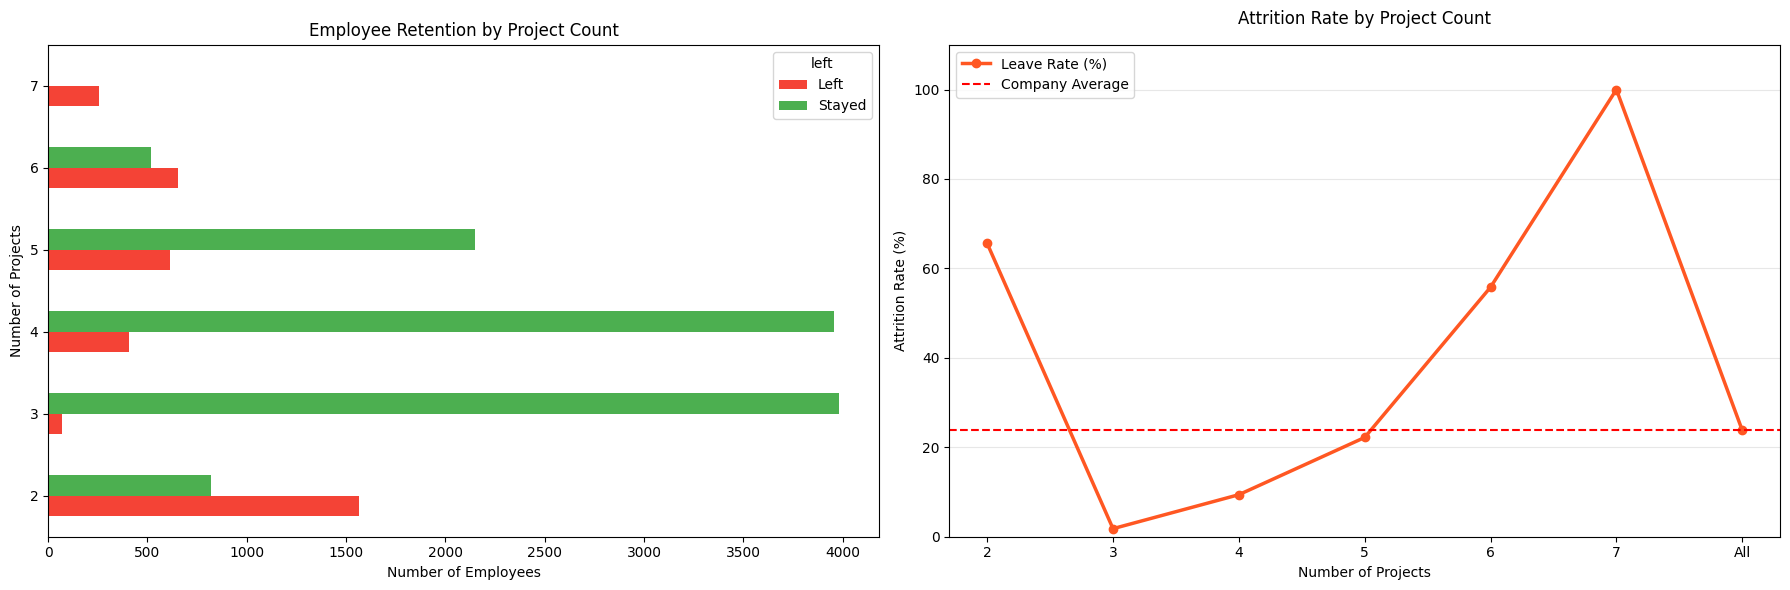

In [ ]:


# --- First Plot Data ---
retention_by_projects = pd.crosstab(main_df['number_project'], main_df['left'].map({True: 'Left', False: 'Stayed'}))

# --- Second Plot Data ---
attrition_rate = project_retention['Leave Rate (%)']

# --- Create subplots ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))  # 1 row, 2 columns

# --- First subplot ---
retention_by_projects.plot(
    kind='barh',
    color=['#F44336', '#4CAF50'],
    ax=axes[0]  # plot on the first subplot
)
axes[0].set_xlabel('Number of Employees')
axes[0].set_ylabel('Number of Projects')
axes[0].set_title('Employee Retention by Project Count')

# --- Second subplot ---
attrition_rate.plot(
    marker='o',
    color='#FF5722',
    linewidth=2.5,
    ax=axes[1]  # plot on the second subplot
)
axes[1].set_title('Attrition Rate by Project Count', pad=15)
axes[1].set_xlabel('Number of Projects')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_ylim(0, 110)
axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(y=attrition_rate['All'], color='r', linestyle='--', label='Company Average')
axes[1].legend()

# --- Adjust Layout ---
plt.tight_layout()
plt.show()


 Keep teams in the 3-4 project "sweet spot."

In [ ]:

hours_retention = pd.crosstab(
    main_df['average_montly_hours'],
    main_df['left'].map({True: 'Left', False: 'Stayed'}),

)
hours_retention


left,Left,Stayed
average_montly_hours,,
96,0,6
97,0,14
98,0,23
99,0,11
100,0,19
...,...,...
306,18,0
307,14,0
308,20,0


In [ ]:
# Create pivot table
pivot_retention = main_df.pivot_table(
    index=pd.cut(main_df['average_montly_hours'], bins=range(100, 350, 25)),
    columns='left',
    aggfunc='size',
    fill_value=0
).rename(columns={False: 'Stayed', True: 'Left'})

# Add metrics
pivot_retention['Attrition_Rate'] = pivot_retention['Left'] / pivot_retention.sum(axis=1) * 100

print(pivot_retention)

left                  Stayed  Left  Attrition_Rate
average_montly_hours                              
(100, 125]               413     0        0.000000
(125, 150]              1481  1086       42.306194
(150, 175]              1995   528       20.927467
(175, 200]              1906    42        2.156057
(200, 225]              1825   148        7.501267
(225, 250]              1775   525       22.826087
(250, 275]              1783   710       28.479743
(275, 300]               177   373       67.818182
(300, 325]                 0   159      100.000000


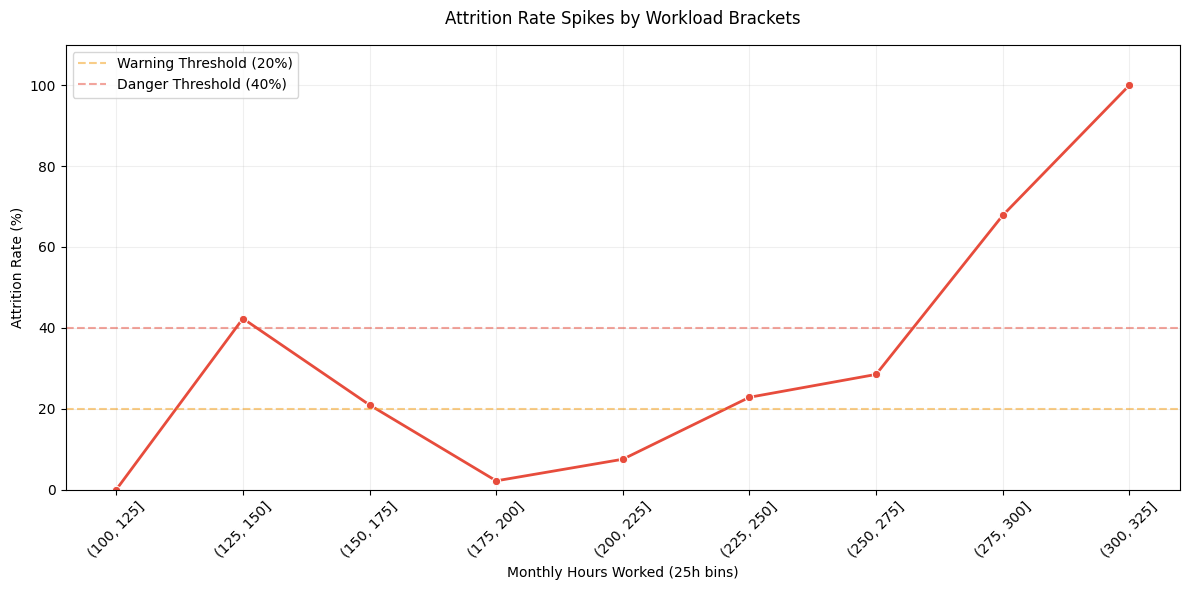

In [ ]:
plt.figure(figsize=(12,6))
ax = sns.lineplot(
    x=pivot_retention.index.astype(str),
    y='Attrition_Rate',
    data=pivot_retention,
    marker='o',
    color='#e74c3c',
    linewidth=2
)

# Highlight critical zones
ax.axhline(y=20, color='#f39c12', linestyle='--', alpha=0.5, label='Warning Threshold (20%)')
ax.axhline(y=40, color='#e74c3c', linestyle='--', alpha=0.5, label='Danger Threshold (40%)')


ax.set_title('Attrition Rate Spikes by Workload Brackets', pad=15)
ax.set_xlabel('Monthly Hours Worked (25h bins)')
ax.set_ylabel('Attrition Rate (%)')
ax.set_xticklabels(pivot_retention.index.astype(str), rotation=45)
ax.set_ylim(0, 110)
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

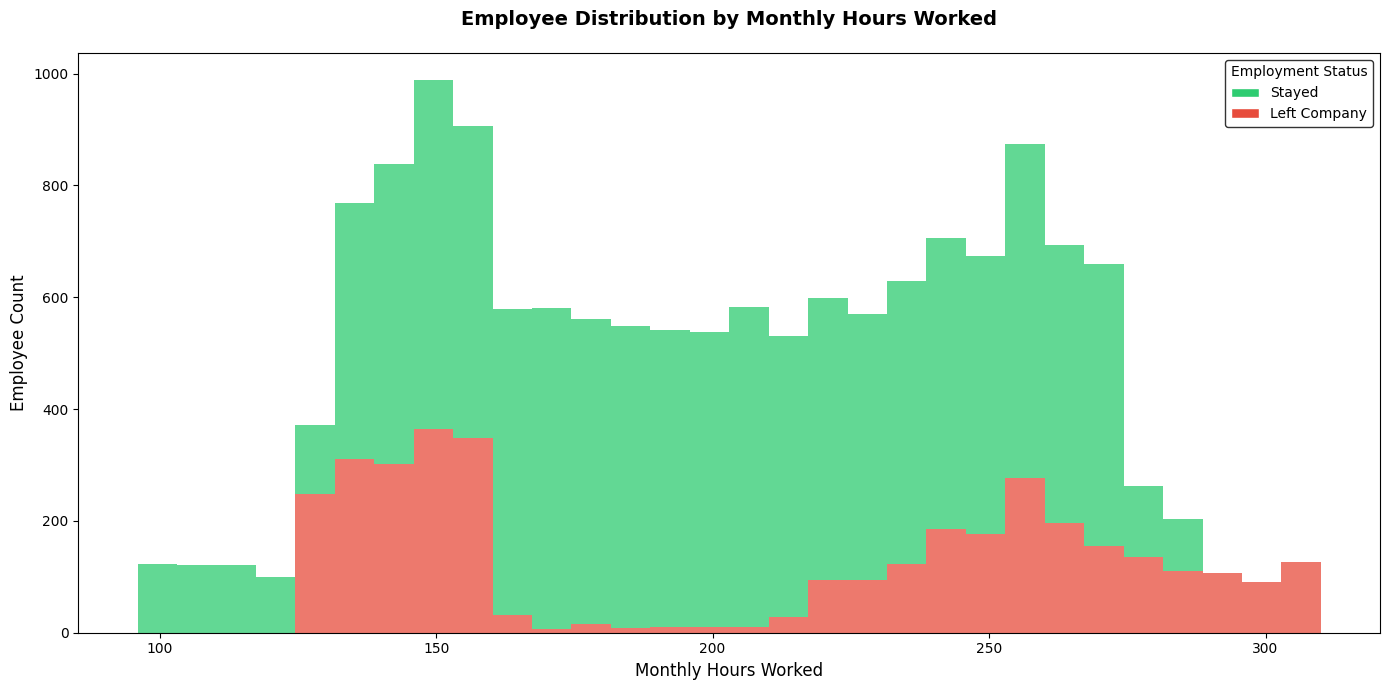

In [ ]:
# Create figure and axis
plt.figure(figsize=(14, 7))
ax = sns.histplot(
    data=main_df,
    x='average_montly_hours',
    hue='left',
    bins=30,
    multiple='stack',
    palette={False: '#2ecc71', True: '#e74c3c'},
    edgecolor='white',
    linewidth=0.
)

# Set labels using axis methods
ax.set_title('Employee Distribution by Monthly Hours Worked',
            pad=20, fontsize=14, fontweight='bold')
ax.set_xlabel('Monthly Hours Worked', fontsize=12)
ax.set_ylabel('Employee Count', fontsize=12)

# Create legend
legend_labels = {False: 'Stayed', True: 'Left Company'}
handles = [plt.Rectangle((0,0),1,1, color='#2ecc71', ec='white'),
           plt.Rectangle((0,0),1,1, color='#e74c3c', ec='white')]
ax.legend(handles, [legend_labels[False], legend_labels[True]],
         title='Employment Status',
         frameon=True,
         edgecolor='black')



plt.tight_layout()
plt.show()


Extreme Cases:

300+ hours: 100% attrition (all employees leave)

275-300h: 2/3 employees quit

Safe Range:100, 125( 0 %) ,175-200h  (2.2%)

## **1) Categorical Data Analysis**

***Balance of classes***

left
False    11428
True      3571
Name: count, dtype: int64


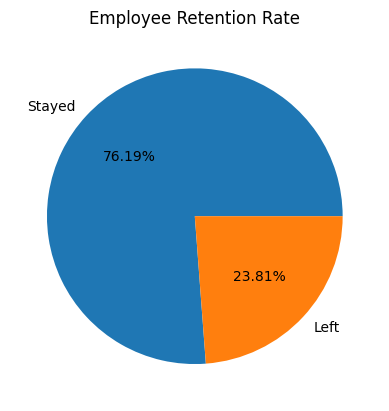

In [ ]:
data = main_df['left'].value_counts().sort_index()  # Sort to ensure 0 comes before 1
print(data)

labels = ['Stayed', 'Left']
plt.pie(data, labels=labels, autopct='%1.2f%%')
plt.title('Employee Retention Rate')
plt.show()

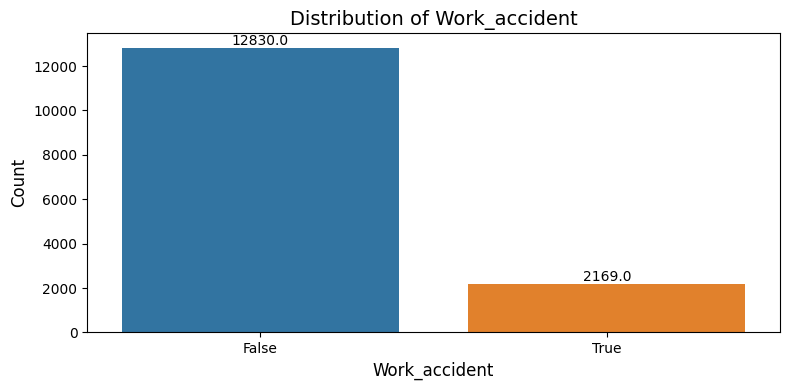

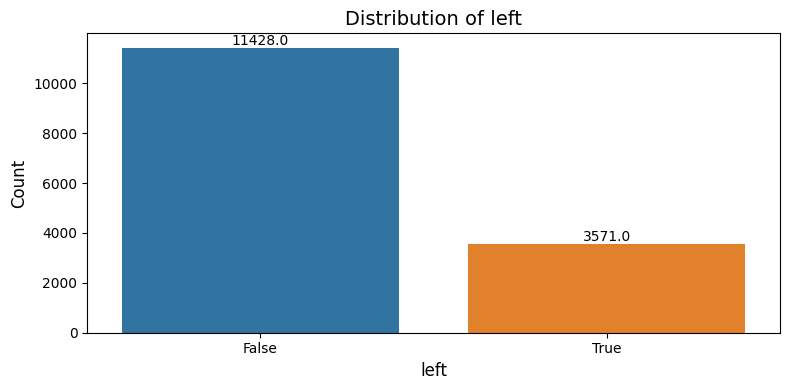

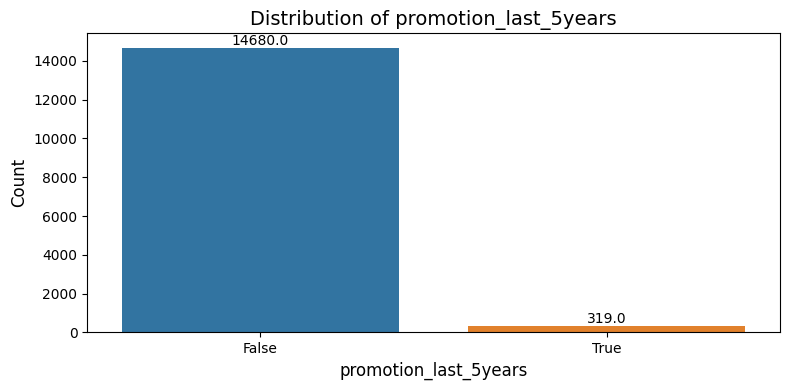

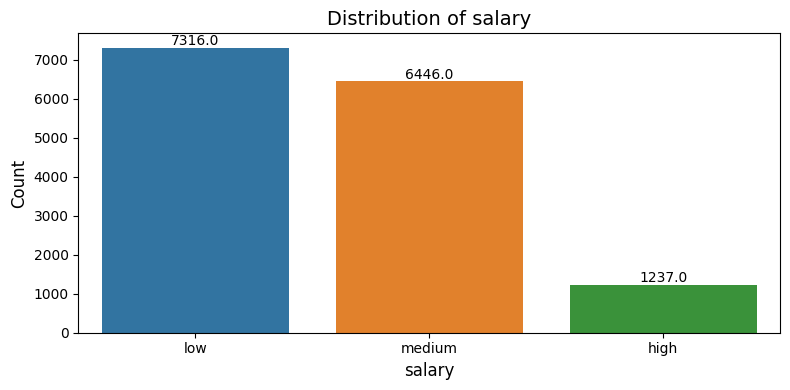

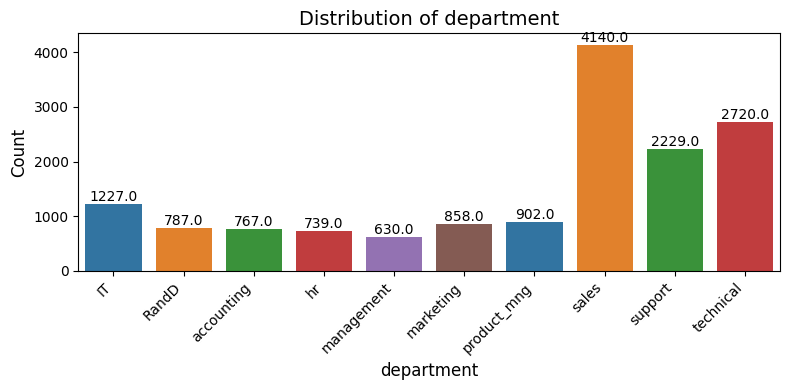

In [ ]:
# Define your custom color palette (replace with your preferred colors)
custom_palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]

for column in df_cat.columns:
    plt.figure(figsize=(8, 4))

    ax = sns.countplot(
        x=column,
        data=df_cat,
        palette=custom_palette  # Uses custom colors
    )

    plt.title(f'Distribution of {column}', fontsize=14)
    plt.xlabel(column, fontsize=12)
    plt.ylabel('Count', fontsize=12)

    if len(df_cat[column].unique()) > 5:
        plt.xticks(rotation=45, ha='right')

    for p in ax.patches:
        ax.annotate(
            f'{p.get_height()}',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='center',
            xytext=(0, 5),
            textcoords='offset points',
            fontsize=10
        )

    plt.tight_layout()
    plt.show()

In [ ]:

salary_dist = pd.crosstab(main_df['department'], main_df['salary'], normalize='index') * 100

salary_dist.style.format("{:.1f}%")



salary,low,medium,high
department,,,
IT,49.6%,43.6%,6.8%
RandD,46.3%,47.3%,6.5%
accounting,46.7%,43.7%,9.6%
hr,45.3%,48.6%,6.1%
management,28.6%,35.7%,35.7%
marketing,46.9%,43.8%,9.3%
product_mng,50.0%,42.5%,7.5%
sales,50.7%,42.8%,6.5%
support,51.4%,42.3%,6.3%


In [ ]:
df_cat.columns

Index(['Work_accident', 'left', 'promotion_last_5years', 'salary',
       'department'],
      dtype='object')

In [ ]:
# Comparing left and each of these categorical variables
pd.crosstab(main_df.left,main_df.Work_accident)

Work_accident,False,True
left,,
False,9428,2000
True,3402,169


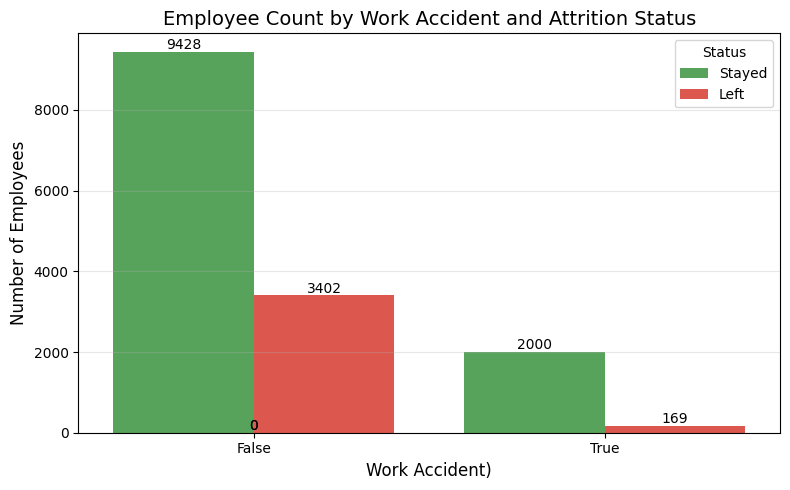

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=main_df,
             x='Work_accident',
             hue='left',
             palette={0: '#4CAF50', 1: '#F44336'})

plt.title('Employee Count by Work Accident and Attrition Status', fontsize=14)
plt.xlabel('Work Accident)', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
plt.legend(title='Status', labels=['Stayed', 'Left'])
plt.grid(axis='y', alpha=0.3)

# Add value labels
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.0f}',
                      (p.get_x()+p.get_width()/2., p.get_height()),
                      ha='center', va='center',
                      xytext=(0,5),
                      textcoords='offset points')
plt.tight_layout()
plt.show()

In [ ]:
# Comparing left and each of these categorical variables
pd.crosstab(main_df.left,main_df.salary)

salary,low,medium,high
left,,,
False,5144,5129,1155
True,2172,1317,82


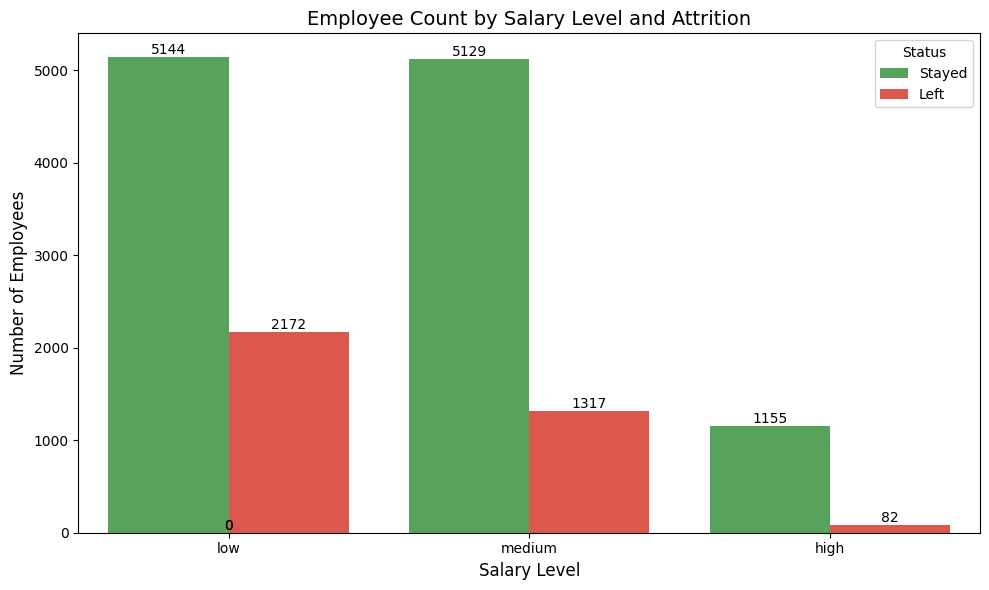

In [ ]:
plt.figure(figsize=(10,6))
ax = sns.countplot(data=main_df,
                  x='salary',
                  hue='left',
                  palette={0:'#4CAF50',1:'#F44336'},  # Color mapping
                  order=['low','medium','high'])  # Ensure logical ordering

plt.title('Employee Count by Salary Level and Attrition', fontsize=14)
plt.xlabel('Salary Level', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
plt.legend(title='Status', labels=['Stayed', 'Left'])

# Add value labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}',
               (p.get_x()+p.get_width()/2., p.get_height()),
               ha='center', va='center',
               xytext=(0,5),
               textcoords='offset points')
plt.tight_layout()
plt.show()

In [ ]:
pd.crosstab( main_df.promotion_last_5years,main_df.left)

left,False,True
promotion_last_5years,,
False,11128,3552
True,300,19


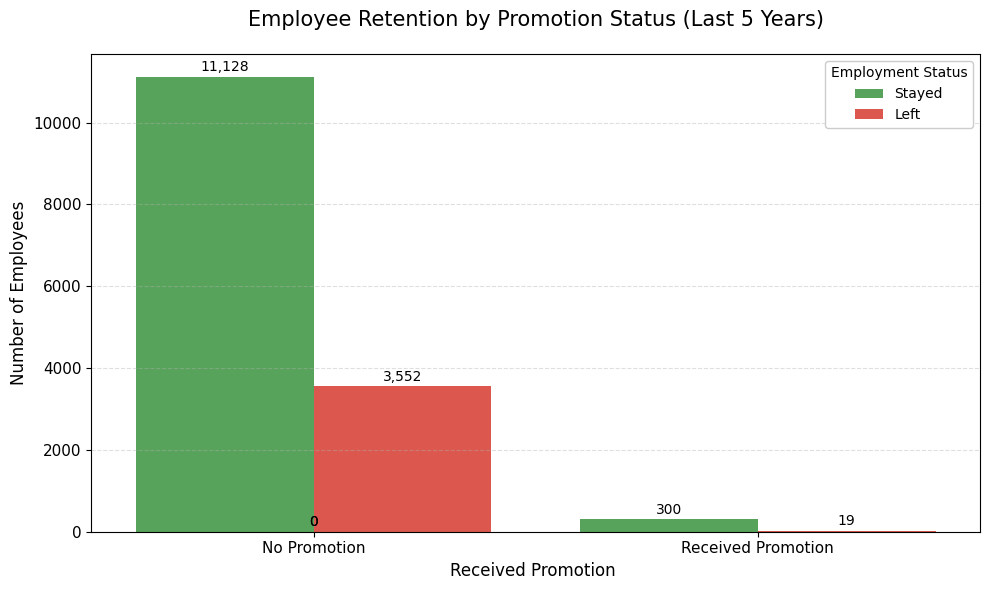

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=main_df,
                 x='promotion_last_5years',
                 hue='left',
                 palette={False: '#4CAF50', True: '#F44336'},  # Green for stayed, red for left
                 order=[False, True])  # Ensure proper ordering

# Customize title and labels
plt.title('Employee Retention by Promotion Status (Last 5 Years)', fontsize=15, pad=20)
plt.xlabel('Received Promotion ', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)

# Improve legend
plt.legend(title='Employment Status',
          labels=['Stayed', 'Left'],
          loc='upper right',
          framealpha=1)

# Add precise value labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',  # Format with thousands separator
               (p.get_x() + p.get_width()/2., p.get_height()),
               ha='center', va='center',
               xytext=(0, 7),  # Slightly higher position
               textcoords='offset points',
               fontsize=10)

# Customize ticks and grid
plt.xticks([0, 1], ['No Promotion', 'Received Promotion'], fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Add footnote with sample size (fixed calculation)
total_samples = len(main_df)
promotion_rate = main_df['promotion_last_5years'].value_counts(normalize=True).get(1, 0)*100


plt.tight_layout()
plt.show()

In [ ]:
pd.crosstab(main_df.department,main_df.left)

left,False,True
department,,
IT,954,273
RandD,666,121
accounting,563,204
hr,524,215
management,539,91
marketing,655,203
product_mng,704,198
sales,3126,1014
support,1674,555


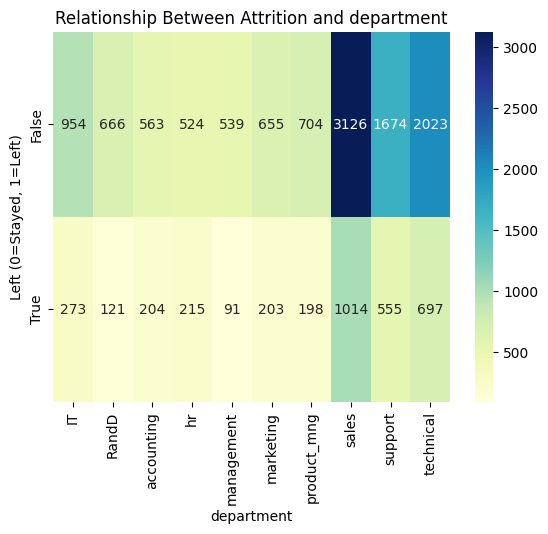

In [ ]:
cross_tab = pd.crosstab(main_df.left, main_df.department)
sns.heatmap(cross_tab, annot=True, fmt='d', cmap="YlGnBu")
plt.title("Relationship Between Attrition and department")
plt.xlabel("department")
plt.ylabel("Left (0=Stayed, 1=Left)")
plt.show()

In [ ]:


# Convert 'left' to numeric if it's categorical
main_df['left_numeric'] = main_df['left'].astype(int)

# Create the attrition analysis DataFrame
attrition_df = (
    main_df.groupby('department')
    .agg(
        Total_Employees=('left_numeric', 'count'),
        Employees_Left=('left_numeric', 'sum')
    )
    .reset_index()
)

# Calculate attrition rate
attrition_df['Attrition_Rate'] = (
    (attrition_df['Employees_Left'] / attrition_df['Total_Employees']) * 100
).round(1)

# Sort by highest attrition
attrition_df = attrition_df.sort_values('Attrition_Rate', ascending=False)

# Format the numbers (optional)
attrition_df['Total_Employees'] = attrition_df['Total_Employees'].map('{:,}'.format)
attrition_df['Employees_Left'] = attrition_df['Employees_Left'].map('{:,}'.format)
attrition_df['Attrition_Rate'] = attrition_df['Attrition_Rate'].map('{}%'.format)

# Rename columns for display
attrition_df.columns = [
    'Department',
    'Total Employees',
    'Employees Left',
    'Attrition Rate'
]

attrition_df

,Department,Total Employees,Employees Left,Attrition Rate
3,hr,739,215,29.1%
2,accounting,767,204,26.6%
9,technical,"2,720",697,25.6%
8,support,"2,229",555,24.9%
7,sales,"4,140","1,014",24.5%
5,marketing,858,203,23.7%
0,IT,"1,227",273,22.2%
6,product_mng,902,198,22.0%
1,RandD,787,121,15.4%
4,management,630,91,14.4%


In [ ]:

# Convert all boolean columns in the DataFrame to integers (0 or 1)
main_df = main_df.apply(lambda x: x.astype(int) if x.dtype == 'bool' else x)
main_df

,employee_id,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary,satisfaction_level,last_evaluation
0,1003,2,157,3,0,1,0,sales,low,0.38,0.53
1,1005,5,262,6,0,1,0,sales,medium,0.80,0.86
2,1486,7,272,4,0,1,0,sales,medium,0.11,0.88
3,1038,5,223,5,0,1,0,sales,low,0.72,0.87
4,1057,2,159,3,0,1,0,sales,low,0.37,0.52
...,...,...,...,...,...,...,...,...,...,...,...
14994,87670,2,151,3,0,1,0,support,low,0.40,0.57
14995,87673,2,160,3,0,1,0,support,low,0.37,0.48
14996,87679,2,143,3,0,1,0,support,low,0.37,0.53
14997,87681,6,280,4,0,1,0,support,low,0.11,0.96


# **Data Preprocessing**


*   Handling missing values
*   Handling outlier

*   Encoding categorical variables
*   Feature scaling

* Feature selection






In [ ]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = main_df.drop(['employee_id', 'left'], axis=1)
y = main_df['left']

# Split data (stratified to preserve class imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Ensures same 90:10 ratio in both train & test
)


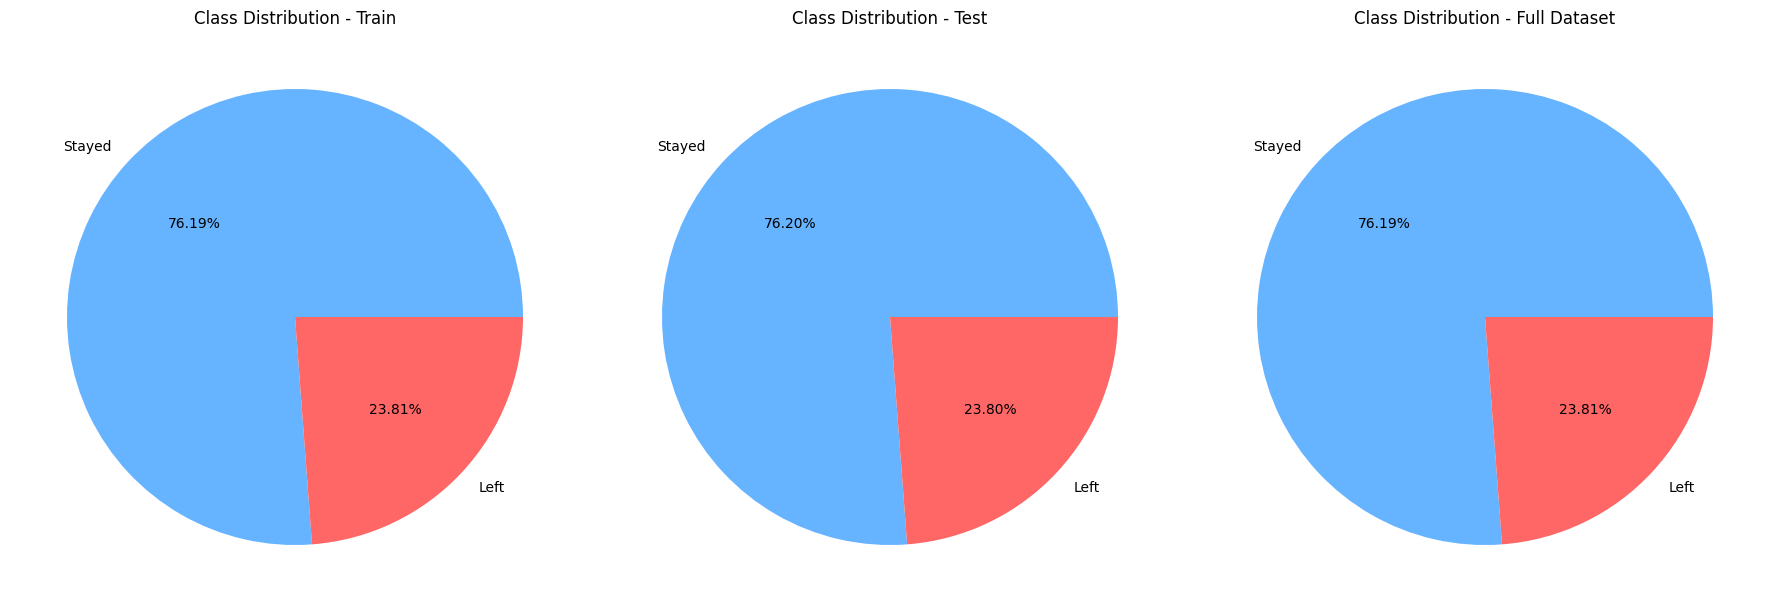

In [ ]:
#left (stayed vs leave in train , test , dataframe )
# Labels for the pie chart
labels = ['Stayed', 'Left']

# Data for the pie chart
train_data = y_train.value_counts()
test_data = y_test.value_counts()
full_data = y.value_counts()

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot for Train data
axes[0].pie(train_data, labels=labels, autopct='%1.2f%%', colors=['#66b3ff', '#ff6666'])
axes[0].set_title('Class Distribution - Train')

# Plot for Test data
axes[1].pie(test_data, labels=labels, autopct='%1.2f%%', colors=['#66b3ff', '#ff6666'])
axes[1].set_title('Class Distribution - Test')

# Plot for Full data (entire dataset)
axes[2].pie(full_data, labels=labels, autopct='%1.2f%%', colors=['#66b3ff', '#ff6666'])
axes[2].set_title('Class Distribution - Full Dataset')

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
# Define column types
numerical_cols = ['number_project', 'average_montly_hours', 'time_spend_company',
                 'satisfaction_level', 'last_evaluation']
binary_cols = ['Work_accident', 'promotion_last_5years']
ordinal_cols = ['salary']
nominal_cols = ['department']
# Salary order
salary_order = ['low', 'medium', 'high']

In [ ]:
!pip install category-encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 3.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from category_encoders import TargetEncoder
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ----------------------------------------
# Define custom transformer: Outlier Capper
# ----------------------------------------
class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, factor=1.5):
        self.factor = factor
        self.upper_bounds = {}

    def fit(self, X, y=None):
        for col in X.columns:
            q1 = X[col].quantile(0.25)
            q3 = X[col].quantile(0.75)
            iqr = q3 - q1
            self.upper_bounds[col] = q3 + self.factor * iqr
        return self

    def transform(self, X):
        X = X.copy()
        for col in X.columns:
            if col in self.upper_bounds:
                X[col] = np.where(X[col] > self.upper_bounds[col], self.upper_bounds[col], X[col])
        return X

# ----------------------------------------
# Define column groups (replace with yours)
# ----------------------------------------
numerical_cols = ['number_project', 'average_montly_hours', 'time_spend_company',
                 'satisfaction_level', 'last_evaluation']
binary_cols = ['Work_accident', 'promotion_last_5years']
ordinal_cols = ['salary']
nominal_cols = ['department']
# Salary order
salary_order = ['low', 'medium', 'high']

# ----------------------------------------
# Pipelines for each type
# ----------------------------------------
numeric_transformer = Pipeline(steps=[
    ('outliers', OutlierCapper()),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler(with_mean=False))
])

binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Correct the OrdinalEncoder by applying salary_order only to the 'salary' column
ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[salary_order] if 'salary' in ordinal_cols else 'auto'))
])

nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target_enc', TargetEncoder()),
    ('scaler', StandardScaler(with_mean=False))
])

# ----------------------------------------
# Combined ColumnTransformer
# ----------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('binary', binary_transformer, binary_cols),
        ('ordinal', ordinal_transformer, ordinal_cols),
        ('nominal', nominal_transformer, nominal_cols)
    ],
    remainder='drop'
)

# ----------------------------------------
# Training pipeline (with SMOTE)
# ----------------------------------------
training_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42))
])

# ----------------------------------------
# Inference pipeline (without SMOTE)
# ----------------------------------------
inference_pipeline = Pipeline([('preprocessor', preprocessor)])


In [ ]:
training_pipeline


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('outliers',
                                                                   OutlierCapper()),
                                                                  ('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler(with_mean=False))]),
                                                  ['number_project',
                                                   'average_montly_hours',
                                                   'time_spend_company',
                                                   'satisfaction_level',
                                                   'last_evaluation']),
                                                 ('binary',
                                                  Pipeline(steps=[('imputer',
                                                                   Simp...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinal',
                                                                   OrdinalEncoder(categories=[['low',
                                                                                               'medium',
                                                                                               'high']]))]),
                                                  ['salary']),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('target_enc',
                                                                   TargetEncoder()),
                                                                  ('scaler',
                                                                   StandardScaler(with_mean=False))]),
                                                  ['department'])])),
                ('smote', SMOTE(random_state=42))])

In [ ]:
inference_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('outliers',
                                                                   OutlierCapper()),
                                                                  ('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler(with_mean=False))]),
                                                  ['number_project',
                                                   'average_montly_hours',
                                                   'time_spend_company',
                                                   'satisfaction_level',
                                                   'last_evaluation']),
                                                 ('binary',
                                                  Pipeline(steps=[('imputer',
                                                                   Simp...
                                                   'promotion_last_5years']),
                                                 ('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinal',
                                                                   OrdinalEncoder(categories=[['low',
                                                                                               'medium',
                                                                                               'high']]))]),
                                                  ['salary']),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('target_enc',
                                                                   TargetEncoder()),
                                                                  ('scaler',
                                                                   StandardScaler(with_mean=False))]),
                                                  ['department'])]))])

In [ ]:
# Fit and transform using the training pipeline (this includes preprocessing + SMOTE)
X_train_preprocessed, y_train_balanced = training_pipeline.fit_resample(X_train, y_train)

# Convert X_train_preprocessed into DataFrame for better visualization (assumes that X_train is a DataFrame)
X_train_preprocessed_df = pd.DataFrame(X_train_preprocessed, columns=numerical_cols + binary_cols + ordinal_cols + nominal_cols)

# Display the transformed data
X_train_preprocessed_df.head()


,number_project,average_montly_hours,time_spend_company,satisfaction_level,last_evaluation,Work_accident,promotion_last_5years,salary,department
0,3.245685,4.945947,3.680607,2.937927,3.626463,0.0,0.0,0.0,7.282133
1,4.057106,4.725682,4.600759,3.139155,5.849133,0.0,0.0,1.0,7.282133
2,1.622843,4.945947,3.680607,0.402456,3.217023,0.0,0.0,1.0,7.282133
3,1.622843,2.523033,2.760455,2.374489,2.983058,0.0,0.0,1.0,7.282133
4,3.245685,5.026043,3.680607,2.736699,2.807584,0.0,0.0,2.0,7.164635


Missing values after preprocessing:
number_project           0
average_montly_hours     0
time_spend_company       0
satisfaction_level       0
last_evaluation          0
Work_accident            0
promotion_last_5years    0
salary                   0
department               0
dtype: int64
_________________________________________________________

Class Distribution Before SMOTE:
left
0    9142
1    2857
Name: count, dtype: int64

Class Distribution After SMOTE:
left
0    9142
1    9142
Name: count, dtype: int64
_________________________________________________________


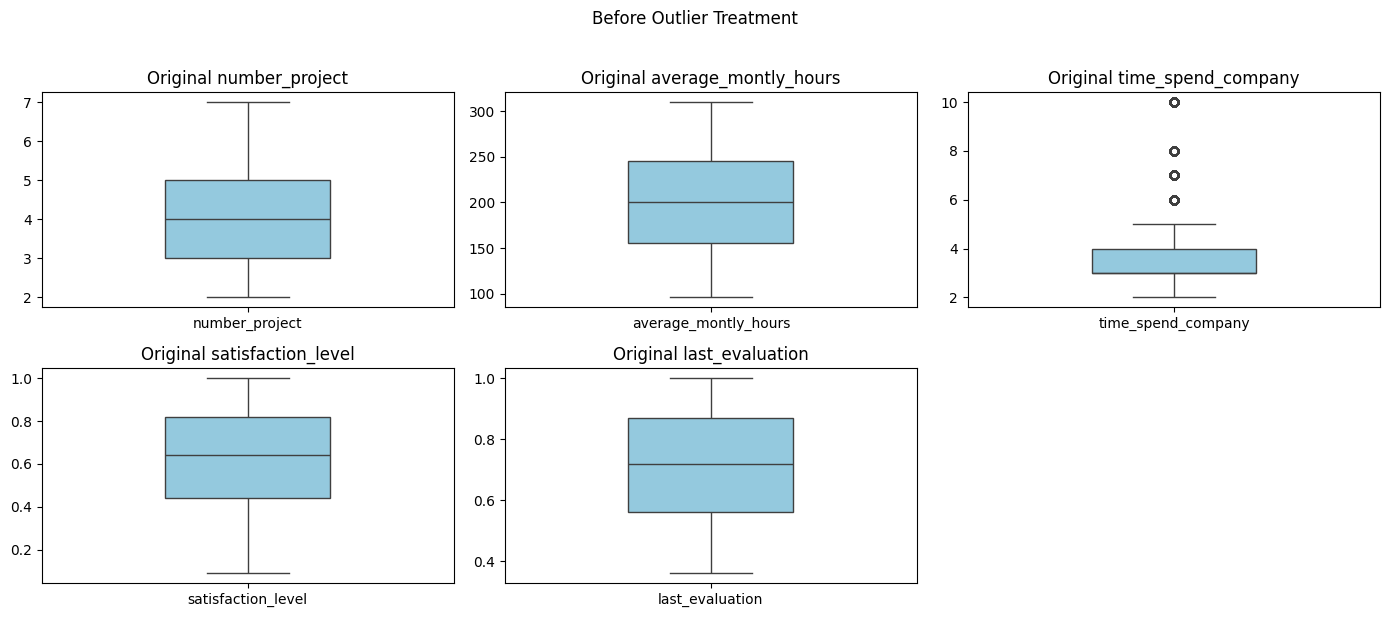

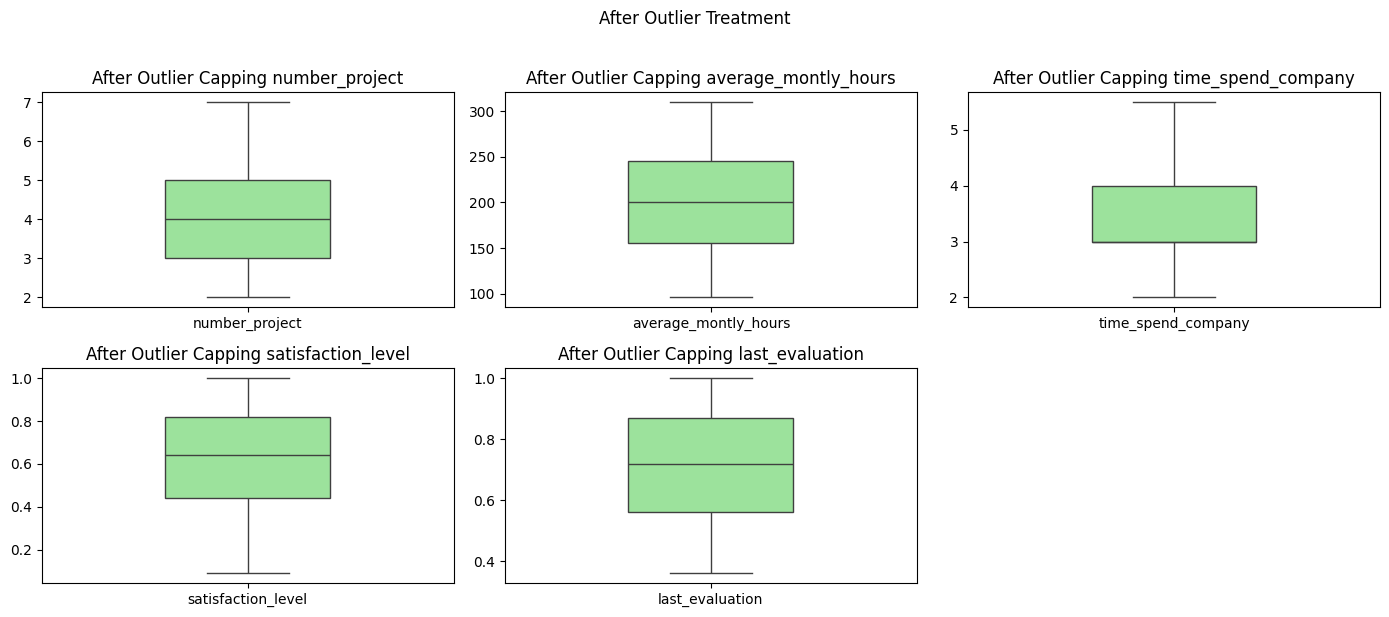

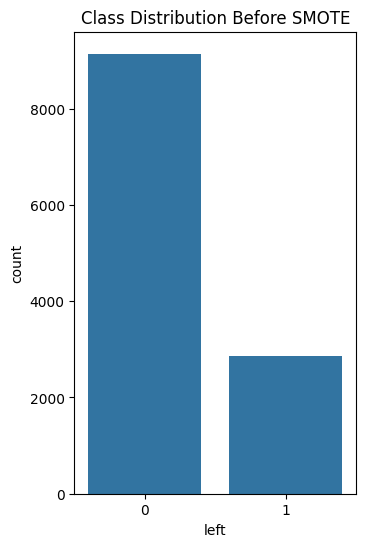

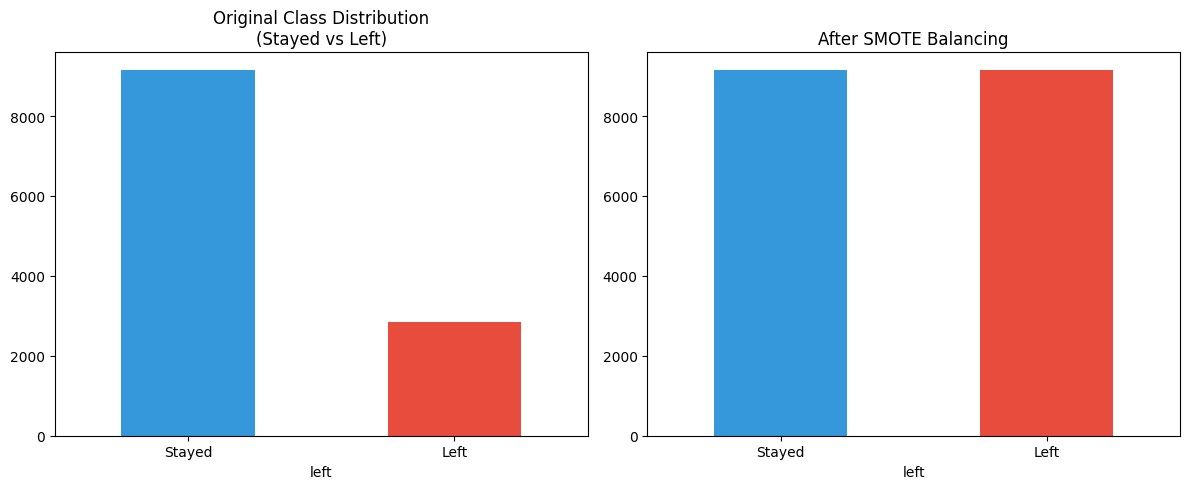

In [ ]:
# =============================================
# FINAL OUTPUTS
# =============================================

# 1. Display Missing Values After Preprocessing
print("Missing values after preprocessing:")
print(X_train_preprocessed_df.isnull().sum())
print("_________________________________________________________")

# 2. Class Distribution (Before and After)
print("\nClass Distribution Before SMOTE:")
print(y_train.value_counts())

print("\nClass Distribution After SMOTE:")
print(pd.Series(y_train_balanced).value_counts())
print("_________________________________________________________")
# =============================================
# 1. Outlier Handling Before/After
# =============================================

plt.figure(figsize=(14, 6))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=X_train[[col]], color='skyblue', width=0.4)
    plt.title(f'Original {col}')
plt.suptitle('Before Outlier Treatment', y=1.02)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    capped = OutlierCapper().fit_transform(X_train[[col]])
    sns.boxplot(data=capped, color='lightgreen', width=0.4)
    plt.title(f'After Outlier Capping {col}')
plt.suptitle('After Outlier Treatment', y=1.02)
plt.tight_layout()
plt.show()



# =============================================
# 2. Class Distribution Before/After SMOTE
# =============================================

# Original class distribution
plt.figure(figsize=(8, 6))
plt.subplot(1, 2, 1)
sns.countplot(x=y_train)
plt.title("Class Distribution Before SMOTE")

# Balanced class distribution after SMOTE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
pd.Series(y_train).value_counts().plot(kind='bar', color=['#3498db', '#e74c3c'], ax=ax1)
ax1.set_title('Original Class Distribution\n(Stayed vs Left)')
ax1.set_xticklabels(['Stayed', 'Left'], rotation=0)

pd.Series(y_train_balanced).value_counts().plot(kind='bar', color=['#3498db', '#e74c3c'], ax=ax2)
ax2.set_title('After SMOTE Balancing')
ax2.set_xticklabels(['Stayed', 'Left'], rotation=0)
plt.tight_layout()
plt.show()



# **Modeling**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:

# 1. Define parameter grids
param_grids = {
    'logistic': {
        'C': [0.01, 0.1, 1, 10],
        'penalty': ['l2'],
        'solver': ['liblinear']
    },
    'svm': {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto']
    },
    'knn': {
        'n_neighbors': [3, 5, 7],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    'dt': {
        'criterion': ['gini', 'entropy'],
        'max_depth': [5, 10, 20, 30],  # Added more options
        'min_samples_split': [2, 5, 10],  # Added more options
        'min_samples_leaf': [1, 2, 4],  # Added more options
        'max_features': ['auto', 'sqrt', 'log2', None]  # Added max_features options
    },
    'rf': {
        'n_estimators': [50, 100, 200],  # Added more options
        'max_depth': [5, 10, 20, 30],  # Added more options
        'min_samples_split': [2, 5, 10],  # Added more options
        'min_samples_leaf': [1, 2, 4],  # Added more options
        'max_features': ['auto', 'sqrt', 'log2', None]  # Added max_features options
    }
}

# 2. Define model objects
models = {
    'logistic': LogisticRegression(),
    'svm': SVC(),
    'knn': KNeighborsClassifier(),
    'dt': DecisionTreeClassifier(),
    'rf': RandomForestClassifier()
}

# 3. Track best models and scores
best_models = {}
best_scores = {}

# 4. Perform GridSearchCV for each model
for name, model in models.items():
    print(f"🔍 Grid search for {name.upper()}...")
    grid = GridSearchCV(estimator=model,
                        param_grid=param_grids[name],
                        scoring='accuracy',
                        cv=5,
                        n_jobs=-1)
    grid.fit(X_train_preprocessed, y_train_balanced)
    best_models[name] = grid.best_estimator_
    best_scores[name] = grid.best_score_



    print(f"✅ Best {name.upper()} parameters: {grid.best_params_}")
    print(f"📊 Cross-validation Accuracy: {grid.best_score_:.4f}")
    print("-" * 50)

# 5. Select the best model overall
best_model_name = max(best_scores, key=best_scores.get)
overall_best_model = best_models[best_model_name]

print(f"\n🏆 Best Overall Model: {best_model_name.upper()}")
print(f"✅ Accuracy: {best_scores[best_model_name]:.4f}")


🔍 Grid search for LOGISTIC...
✅ Best LOGISTIC parameters: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
📊 Cross-validation Accuracy: 0.8107
--------------------------------------------------
🔍 Grid search for SVM...
✅ Best SVM parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
📊 Cross-validation Accuracy: 0.9612
--------------------------------------------------
🔍 Grid search for KNN...
✅ Best KNN parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
📊 Cross-validation Accuracy: 0.9755
--------------------------------------------------
🔍 Grid search for DT...
✅ Best DT parameters: {'criterion': 'gini', 'max_depth': 30, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
📊 Cross-validation Accuracy: 0.9769
--------------------------------------------------
🔍 Grid search for RF...
✅ Best RF parameters: {'max_depth': 30, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
📊 Cross-validation Accuracy: 

In [ ]:
best_models[best_model_name]

RandomForestClassifier(max_depth=30, max_features='log2', n_estimators=200)


Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2286
           1       0.99      0.96      0.98       714

    accuracy                           0.99      3000
   macro avg       0.99      0.98      0.98      3000
weighted avg       0.99      0.99      0.99      3000

 Training Accuracy: 1.0000
Testing Accuracy: 0.9883


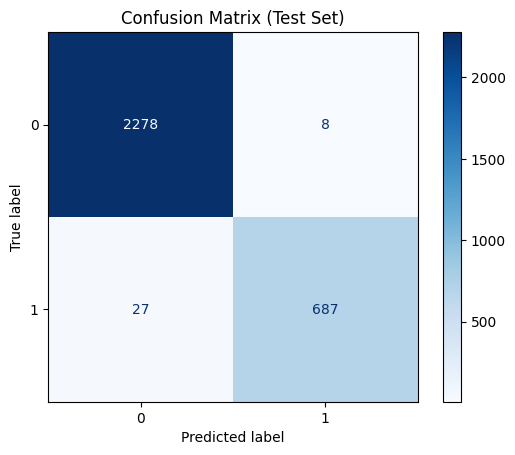

In [ ]:
# 1. Fit best model
best_model = best_models[best_model_name]
best_model.fit(X_train_preprocessed, y_train_balanced)

# 2. Predict
y_train_pred = best_model.predict(X_train_preprocessed)
y_test_pred = best_model.predict(inference_pipeline.transform(X_test))  # Use preprocessing pipeline

# 3. Classification Report
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

# 4. Accuracy
print(f" Training Accuracy: {accuracy_score(y_train_balanced, y_train_pred):.4f}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")



# 6. Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Test Set)")
plt.show()

 Decision Tree - Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      2286
           1       0.94      0.96      0.95       714

    accuracy                           0.98      3000
   macro avg       0.96      0.97      0.97      3000
weighted avg       0.98      0.98      0.98      3000

 Training Accuracy: 1.0000
 Testing Accuracy: 0.9763


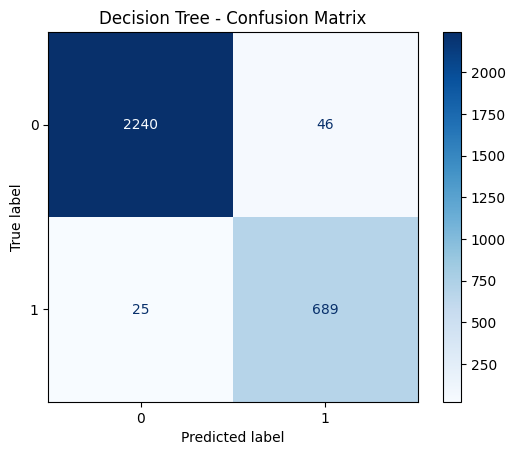

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load the best DT model
best_dt = best_models['dt']
best_dt.fit(X_train_preprocessed, y_train_balanced)

# Predictions
y_train_pred_dt = best_dt.predict(X_train_preprocessed)
y_test_pred_dt = best_dt.predict(inference_pipeline.transform(X_test))

# Metrics
print(" Decision Tree - Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred_dt))

print(f" Training Accuracy: {accuracy_score(y_train_balanced, y_train_pred_dt):.4f}")
print(f" Testing Accuracy: {accuracy_score(y_test, y_test_pred_dt):.4f}")

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_test_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp.plot(cmap=plt.cm.Blues)  # FIXED line
plt.title("Decision Tree - Confusion Matrix")
plt.show()


KNN - Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      2286
           1       0.90      0.97      0.93       714

    accuracy                           0.97      3000
   macro avg       0.94      0.97      0.95      3000
weighted avg       0.97      0.97      0.97      3000

Training Accuracy: 1.0000
Testing Accuracy: 0.9660


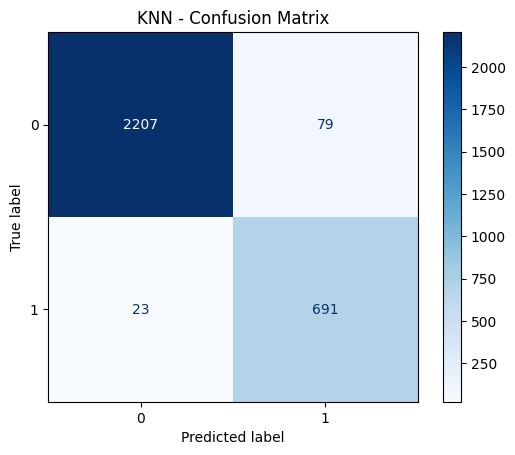

In [ ]:


# Load the best KNN model
best_knn = best_models['knn']
best_knn.fit(X_train_preprocessed, y_train_balanced)

# Predictions
y_train_pred_knn = best_knn.predict(X_train_preprocessed)
X_test_preprocessed = inference_pipeline.transform(X_test)
y_test_pred_knn = best_knn.predict(X_test_preprocessed)

# Metrics
print("KNN - Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred_knn))

print(f"Training Accuracy: {accuracy_score(y_train_balanced, y_train_pred_knn):.4f}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_test_pred_knn):.4f}")

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_test_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn)
disp.plot(cmap=plt.cm.Blues)
plt.title("KNN - Confusion Matrix")
plt.show()


SVM - Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2286
           1       0.93      0.94      0.93       714

    accuracy                           0.97      3000
   macro avg       0.95      0.96      0.96      3000
weighted avg       0.97      0.97      0.97      3000

Training Accuracy: 0.9663
Testing Accuracy: 0.9680


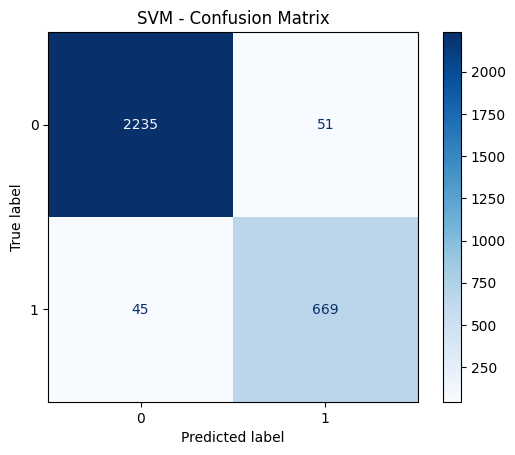

In [ ]:
# Load and fit the best SVM model
best_svm = best_models['svm']
best_svm.fit(X_train_preprocessed, y_train_balanced)

# Predictions
y_train_pred_svm = best_svm.predict(X_train_preprocessed)
X_test_preprocessed = inference_pipeline.transform(X_test)
y_test_pred_svm = best_svm.predict(X_test_preprocessed)

# Metrics
print("SVM - Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred_svm))

print(f"Training Accuracy: {accuracy_score(y_train_balanced, y_train_pred_svm):.4f}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_test_pred_svm):.4f}")

# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_test_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm)
disp.plot(cmap=plt.cm.Blues)
plt.title("SVM - Confusion Matrix")
plt.show()


"Although the Decision Tree, K-Nearest Neighbors (KNN), and Random Forest models achieved higher accuracy scores, they exhibited signs of overfitting—demonstrated by perfect or near-perfect training accuracy and slightly lower test performance. In contrast, the Support Vector Machine (SVM) model achieved a strong test accuracy (96.8%) with a closely matching training accuracy (96.6%), indicating good generalization without overfitting. Therefore, the SVM model is selected as the best-performing and most robust model."



In [ ]:
# ----------------------------------------
# Full training pipeline with SMOTE
# ----------------------------------------
training_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),  # Preprocessing steps with SMOTE during training
    ('smote', SMOTE(random_state=42)),  # SMOTE to handle imbalance
    ('model', best_models['svm'])  # SVM model to be tuned
])
inference_pipeline = Pipeline([
    ('preprocessor', preprocessor),  # Preprocessing steps (no SMOTE for inference)
    ('model', best_models['svm'])    # SVM model that was already trained with SMOTE during training
])
inference_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('outliers',
                                                                   OutlierCapper()),
                                                                  ('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler(with_mean=False))]),
                                                  ['number_project',
                                                   'average_montly_hours',
                                                   'time_spend_company',
                                                   'satisfaction_level',
                                                   'last_evaluation']),
                                                 ('binary',
                                                  Pipeline(steps=[('imputer',
                                                                   Simp...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinal',
                                                                   OrdinalEncoder(categories=[['low',
                                                                                               'medium',
                                                                                               'high']]))]),
                                                  ['salary']),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('target_enc',
                                                                   TargetEncoder()),
                                                                  ('scaler',
                                                                   StandardScaler(with_mean=False))]),
                                                  ['department'])])),
                ('model', SVC(C=10, gamma='auto'))])

In [ ]:
# Fit the model with the training data
training_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('outliers',
                                                                   OutlierCapper()),
                                                                  ('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler(with_mean=False))]),
                                                  ['number_project',
                                                   'average_montly_hours',
                                                   'time_spend_company',
                                                   'satisfaction_level',
                                                   'last_evaluation']),
                                                 ('binary',
                                                  Pipeline(steps=[('imputer',
                                                                   Simp...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinal',
                                                                   OrdinalEncoder(categories=[['low',
                                                                                               'medium',
                                                                                               'high']]))]),
                                                  ['salary']),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('target_enc',
                                                                   TargetEncoder()),
                                                                  ('scaler',
                                                                   StandardScaler(with_mean=False))]),
                                                  ['department'])])),
                ('smote', SMOTE(random_state=42)),
                ('model', SVC(C=10, gamma='auto'))])

Training Accuracy: 0.9711
Test Accuracy: 0.9680

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2286
           1       0.93      0.94      0.93       714

    accuracy                           0.97      3000
   macro avg       0.95      0.96      0.96      3000
weighted avg       0.97      0.97      0.97      3000



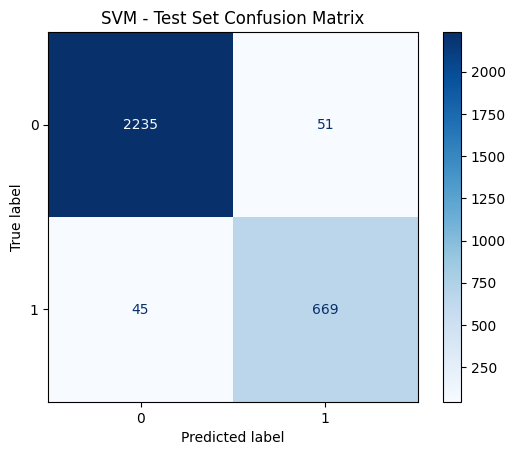

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict on training data
y_train_pred = training_pipeline.predict(X_train)
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")

# Predict on test data
y_test_pred = inference_pipeline.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")

# Classification report
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

# Confusion matrix
cm_test = confusion_matrix(y_test, y_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test)
disp_test.plot(cmap=plt.cm.Blues)
plt.title("SVM - Test Set Confusion Matrix")
plt.show()


In [ ]:
import joblib

# Save the inference pipeline (without SMOTE)
joblib.dump(inference_pipeline, 'svm_inference_pipeline.pkl')


['svm_inference_pipeline.pkl']

In [ ]:
import pandas as pd
import joblib

# New data to predict on (excluding 'employee_id' and 'left')
new_employee_data = pd.DataFrame({
    'number_project': [2],
    'average_montly_hours': [157],
    'time_spend_company': [3],
    'Work_accident': [0],  # Assuming 0 means False
    'promotion_last_5years': [0],  # Assuming 0 means False
    'department': ['sales'],
    'salary': ['low'],
    'satisfaction_level': [0.38],
    'last_evaluation': [0.53]
})

# Load the saved inference pipeline
loaded_inference_pipeline = joblib.load('svm_inference_pipeline.pkl')

# Make predictions
new_employee_prediction = loaded_inference_pipeline.predict(new_employee_data)

# Map the prediction to a human-readable label
prediction_label = "Stayed" if new_employee_prediction[0] == 0 else "Left"

# Output the prediction
print(f"Prediction for the new employee: {prediction_label}")


Prediction for the new employee: Left
